In [58]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [59]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [60]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cpu')

In [61]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Physical parameters
L = 2.0 #
H = 1.0 #
T = 1.0 #
rho = 1000.0 
g = 9.81 
opening_y_min = 0.30 
opening_y_max = 0.70 
p_scale = rho * g * H 

# REALISTIC VISCOSITY
# Note: Re ~ 1.7e6. If training diverges, revert to 1e-3 as a stable validation case.
nu = 1.0e-6 

# 1D analytical draining-height model with a partially submerged outlet.
# odeint calls the callback as dh_dt_ode(h, t).
A_tank = L  # 2D tank cross-sectional area (unit depth)
W_out = 1.0  # outlet width / unit depth
C_d = 0.61

def dh_dt_ode(h, t):
    """Return the draining rate for the current water height.

    Above the opening, the full outlet is active. Within the opening,
    only the submerged portion contributes to the discharge.
    """
    h_value = float(np.asarray(h).reshape(-1)[0])

    if h_value <= opening_y_min:
        Q_out = 0.0
    elif h_value <= opening_y_max:
        active_height = h_value - opening_y_min
        effective_head = active_height / 2.0
        Q_out = C_d * W_out * active_height * np.sqrt(2.0 * g * effective_head)
    else:
        fixed_outlet_height = opening_y_max - opening_y_min
        y_center = (opening_y_max + opening_y_min) / 2.0
        effective_head = h_value - y_center
        Q_out = C_d * W_out * fixed_outlet_height * np.sqrt(2.0 * g * effective_head)

    return -Q_out / A_tank

height_time_grid = np.linspace(0, T, 1000)
height_solution = odeint(dh_dt_ode, H, height_time_grid).flatten()

def h_t(t_tensor):
    """Interpolates h(t) for any PyTorch time tensor"""
    t_np = t_tensor.detach().cpu().numpy()
    h_np = np.interp(t_np, height_time_grid, height_solution)
    return torch.tensor(h_np, dtype=torch.float32, device=t_tensor.device)

def dh_dt(t_tensor):
    """Interpolates dh/dt for the kinematic free-surface condition"""
    t_np = t_tensor.detach().cpu().numpy()
    dh_np = np.array([dh_dt_ode(hi, ti) for hi, ti in zip(np.interp(t_np, height_time_grid, height_solution), t_np)])
    return torch.tensor(dh_np, dtype=torch.float32, device=t_tensor.device)

# Pressure functions using modified pressure p_dyn = P + rho*g*y[cite: 1]
def p_star_outlet(y):
    return rho * g * y

def p_star_free_surface(h):
    return rho * g * h

In [62]:
# Boundary/free-surface validation runs later, after the model and validation helpers are defined.


In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #[cite: 1]

def generate_interior_points(N):
    x_f = np.random.uniform(0, L, N)
    t_f = np.random.uniform(0, T, N)
    
    # Evaluate h(t) to set the dynamic upper bound for y
    h_max = np.interp(t_f, height_time_grid, height_solution)
    y_f = np.random.uniform(0, h_max, N)
    
    X_f = np.column_stack([x_f, y_f, t_f])
    return torch.tensor(X_f, dtype=torch.float32, device=device, requires_grad=True)

X_f = generate_interior_points(10000)

print(f"Fluid domain verification: min(y)={X_f[:,1].min():.3f}, max(y)={X_f[:,1].max():.3f}")
assert torch.all(X_f[:,1] <= h_t(X_f[:,2]) + 1e-5), "Collocation points found above free surface!"

# Free Surface Points: (x, h(t), t) independently sampled
N_fs = 1000
x_fs = np.random.uniform(0, L, N_fs)
t_fs = np.random.uniform(0, T, N_fs)
y_fs = np.interp(t_fs, height_time_grid, height_solution)
X_free_surface = torch.tensor(np.column_stack([x_fs, y_fs, t_fs]), dtype=torch.float32, device=device, requires_grad=True)

# Outlet Points: Unsubmerged checking added
N_open = 500
t_open = np.random.uniform(0, T, N_open)
h_at_t = np.interp(t_open, height_time_grid, height_solution)
# Ensure we only sample outlet points that are actively submerged
submerged_mask = h_at_t > opening_y_min
t_submerged = t_open[submerged_mask]
h_submerged = h_at_t[submerged_mask]

# Generate y values bounded by the water level if it drops below opening_y_max
y_upper_bound = np.minimum(h_submerged, opening_y_max)
y_open = np.random.uniform(opening_y_min, y_upper_bound, len(t_submerged))

X_open = torch.tensor(np.column_stack([np.full(len(t_submerged), L), y_open, t_submerged]), dtype=torch.float32, device=device, requires_grad=True)

# Solid wall points: bottom, left, and right wall segments outside the outlet.
# The moving top boundary is represented by X_free_surface, not by a fixed inlet.
N_wall = 1000

def seg(a, b, n, inc_a=True, inc_b=True):
    m = n + int(not inc_a) + int(not inc_b)
    s = np.linspace(a, b, m)
    return s[(0 if inc_a else 1):(m if inc_b else m - 1)]

def make_boundary_points(x, y):
    x, y = np.broadcast_arrays(np.asarray(x, dtype=float), np.asarray(y, dtype=float))
    return np.column_stack([x, y, np.random.uniform(0.0, T, x.shape[0])])

boundary_groups = {}
boundary_groups["Bottom wall"] = make_boundary_points(seg(0.0, L, N_wall), np.zeros(N_wall))
y_left = seg(0.0, H, N_wall)
boundary_groups["Left wall"] = make_boundary_points(np.zeros_like(y_left), y_left)
y_right_below = seg(0.0, opening_y_min, N_wall // 2, True, False)
y_right_above = seg(opening_y_max, H, N_wall // 2, False, True)
y_right = np.concatenate([y_right_below, y_right_above])
boundary_groups["Right wall"] = make_boundary_points(np.full_like(y_right, L), y_right)

X_wall = torch.tensor(np.vstack(list(boundary_groups.values())), dtype=torch.float32, device=device)

# Initial condition: fluid initially at rest at t = 0.
N_ic = 2000
X_initial = torch.tensor(
    np.column_stack([
        np.random.uniform(0.0, L, N_ic),
        np.random.uniform(0.0, H, N_ic),
        np.zeros(N_ic),
    ]),
    dtype=torch.float32,
    device=device,
)

print("Interior:", X_f.shape)
print("Wall:    ", X_wall.shape)
print("Opening: ", X_open.shape)
print("Free surface:", X_free_surface.shape)
print("Initial: ", X_initial.shape)


Fluid domain verification: min(y)=0.000, max(y)=0.996
Interior: torch.Size([10000, 3])
Wall:     torch.Size([3000, 3])
Opening:  torch.Size([500, 3])
Free surface: torch.Size([1000, 3])
Initial:  torch.Size([2000, 3])


In [64]:
# Obsolete total-loss definition removed; see the active definition below.


In [65]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        
        # Output Scaling: The network inherently outputs O(1) values.
        # We scale the normalized pressure by p_scale (rho * g * H = 9810.0) 
        # inside the graph to match physical units without starving the gradients.
        p_physical = p_norm * p_scale 
        
        return torch.cat([u, v, p_physical], dim=1)

In [66]:
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


tensor([[ 2.8774e-02,  2.3928e-02, -3.6798e+02]], grad_fn=<CatBackward0>)


In [67]:
print(pred[0,0].item())

0.02877393737435341


In [68]:
def derivatives(output, inputs):
    grad = torch.autograd.grad(
        output,
        inputs,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return grad

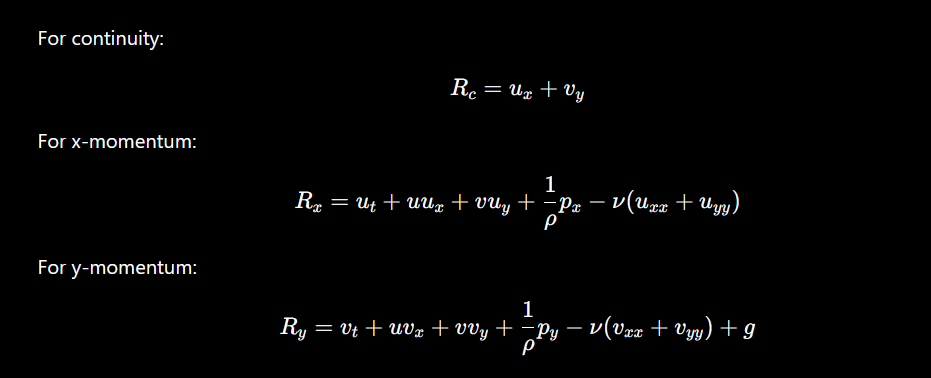

In [69]:
# continuity loss calculation
def continuity_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    v_y = derivatives(v, y)
    
    R_cont = u_x + v_y
    
    return R_cont

In [70]:
# x-momentum loss
# [CHANGED] u, v, p are now 1-D (N,) tensors.  With pred[:, 0:1] (N,1) the product u*u_x ((N,1)*(N,)) broadcast
# to (N,N) and the residual was meaningless.
def x_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0]
    v = pred[:, 1]
    p = pred[:, 2]          # p_dyn;  dP/dx = dp_dyn/dx  (gravity acts only in y)
    
    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    
    u_xx = derivatives(u_x, x)
    u_yy = derivatives(u_y, y)
    
    p_x = derivatives(p, x)

    u_t = derivatives(u, t)
    
    R_x = u_t + u*u_x + v*u_y + ((1/rho)*p_x) - nu*(u_xx + u_yy)
    
    return R_x

In [71]:
# y-momentum loss
# The network predicts the MODIFIED pressure  p_dyn = P + rho*g*y   (P = physical gauge pressure).
#   -(1/rho) dP/dy - g  =  -(1/rho) d(p_dyn)/dy      -> gravity is already inside p_dyn, so NO explicit g here
#   (adding -g again would double-count gravity).
# [CHANGED] 1-D tensors (see x-momentum cell)
def y_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0]
    v = pred[:, 1]
    p_dynamic = pred[:, 2]
    
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)
    
    v_xx = derivatives(v_x, x)
    v_yy = derivatives(v_y, y)

    v_t = derivatives(v, t)
    
    p_y = derivatives(p_dynamic, y)
    
    R_y = v_t + u*v_x + v*v_y + (1/rho)*p_y - nu*(v_xx + v_yy)

    return R_y

In [72]:
print(X_f[:, 0], X_f[:, 1], X_f[:, 2])

tensor([0.7491, 1.9014, 1.4640,  ..., 1.8934, 0.7950, 0.4343],
       grad_fn=<SelectBackward0>) tensor([0.6332, 0.1625, 0.3241,  ..., 0.0173, 0.3388, 0.2410],
       grad_fn=<SelectBackward0>) tensor([0.3736, 0.3329, 0.1762,  ..., 0.3037, 0.4433, 0.1723],
       grad_fn=<SelectBackward0>)


In [73]:
R_cont  = continuity_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_x     = x_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_y     = y_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])

# [NEW] shape guard - all residuals must be (N,)  (the old code produced (N,N) for R_x / R_y)
assert R_cont.shape == R_x.shape == R_y.shape == (X_f.shape[0],), (R_cont.shape, R_x.shape, R_y.shape)

print("Continuity residual:",
      R_cont.abs().mean().item())

print("X momentum residual:",
      R_x.abs().mean().item())

print("Y momentum residual:",
      R_y.abs().mean().item())

Continuity residual: 0.024573002010583878
X momentum residual: 0.34133201837539673
Y momentum residual: 0.24890097975730896


In [74]:
def free_surface_loss(model, X_fs):
    """Applies dynamic pressure and kinematic motion conditions at y = h(t)"""
    pred = model(X_fs)
    v_fs = pred[:, 1]
    p_dynamic = pred[:, 2]
    
    t_tensor = X_fs[:, 2]
    h_tensor = X_fs[:, 1]
    
    # Dynamic condition: P = 0 -> p_dynamic = rho * g * h(t)
    p_target = p_star_free_surface(h_tensor)
    loss_p = torch.mean(((p_dynamic - p_target) / p_scale)**2)
    
    # Kinematic condition: v = dh/dt (assuming flat surface horizontally, h_x = 0)
    v_target = dh_dt(t_tensor)
    
    # Normalize velocity loss scaling based on characteristic velocity ~ 1.0 m/s
    loss_kinematic = torch.mean((v_fs - v_target)**2)
    
    return loss_p + loss_kinematic

# ... (x_momentum_loss, y_momentum_loss, continuity_loss remain structurally identical to the provided correct 1D indexing[cite: 1])



In [75]:
def physics_loss():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)
    R_x = x_momentum_loss(model, x, y, t)
    R_y = y_momentum_loss(model, x, y, t)

    loss_cont = torch.mean(R_cont**2)
    loss_x = torch.mean(R_x**2)
    loss_y = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y

In [76]:
# Wall boundary loss (u=0, v=0)   -- X_wall contains ONLY solid-wall points (no opening, no inlet)
def wall_loss():

    prediction = model(X_wall)

    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]

    loss_u = torch.mean(u_wall**2)
    loss_v = torch.mean(v_wall**2)

    return loss_u + loss_v

In [77]:
# [CHANGED] Opening (outlet) boundary condition:  physical gauge pressure P = 0
#   P = p_dyn - rho*g*y = 0   ->   p_dyn = rho*g*y
# u and v are deliberately NOT constrained here - the outflow must come out of the Navier-Stokes solution.
# The squared error is divided by p_scale^2 only to keep the loss O(1) (same minimiser as the plain MSE).
def opening_loss():
    
    prediction = model(X_open)

    p_dynamic = prediction[:, 2]
    y_open_tensor = X_open[:, 1]

    p_target = p_star_outlet(y_open_tensor)          # = rho * g * y

    return torch.mean(((p_dynamic - p_target) / p_scale)**2)

In [78]:
# Obsolete fixed open-top inlet pressure loss removed; the moving free-surface loss is used instead.


In [79]:
# Initial condition loss  (points X_initial were generated together with the other point sets above)
def ic_loss():
    pred = model(X_initial)
    u_ic = pred[:, 0]
    v_ic = pred[:, 1]
    return torch.mean(u_ic**2) + torch.mean(v_ic**2)

In [80]:
# Total loss: PDE + solid wall + outlet + moving free surface + initial condition
def total_loss():
    L_phys = physics_loss()
    L_wall = wall_loss()
    L_open = opening_loss()
    L_fs = free_surface_loss(model, X_free_surface)
    L_ic = ic_loss()

    loss = (
        L_phys
        + 10.0 * L_wall
        + 10.0 * L_open
        + 10.0 * L_fs
        + 10.0 * L_ic
    )

    return loss, L_phys, L_wall, L_open, L_fs, L_ic


In [81]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=200
)


In [82]:
# [CHANGED] Training from scratch with the corrected problem.
RUN_TRAINING = False  # Ensure this is True to actually run training

epochs_adam = 5000
resample_every = 200   # refresh collocation points periodically
loss_history = []                 
loss_components_history = []      
model_is_trained = False
lbfgs_steps = 0  # Defined at the global cell level

def resample_collocation_points():
    global X_f
    # Keep resampled points below the prescribed moving free surface.
    X_f = generate_interior_points(10000)

checkpoint_path = "pinn_model_03_gravity.pt"

if RUN_TRAINING:
    torch.manual_seed(42); np.random.seed(42)
    model = PINN().to(device)
    
    # --- Phase 1: Adam Optimizer ---
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.5, patience=200)

    print("Starting Phase 1: Adam Training...")
    for epoch in range(epochs_adam):
        if epoch % resample_every == 0 and epoch > 0:
            resample_collocation_points()

        optimizer_adam.zero_grad()
        (loss, L_phys, L_wall, L_open, L_fs, L_ic) = total_loss()
        loss.backward()
        optimizer_adam.step()
        scheduler.step(loss.item())

        loss_history.append(loss.item())
        loss_components_history.append(
            (L_phys.item(), L_wall.item(), L_open.item(), L_fs.item(), L_ic.item())
        )

        if epoch % 100 == 0:
            print(f"Adam Epoch {epoch+1:5d} | Total: {loss.item():.6f} | PDE: {L_phys.item():.6f}")

    # --- Phase 2: L-BFGS Optimizer ---
    print("\nStarting Phase 2: L-BFGS Training...")
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=10000,
        max_eval=12500,
        history_size=50,
        tolerance_grad=1e-5,
        tolerance_change=1.0 * np.finfo(float).eps,
        line_search_fn="strong_wolfe"
    )

    def closure():
        global lbfgs_steps
        optimizer_lbfgs.zero_grad()
        (loss, L_phys, L_wall, L_open, L_fs, L_ic) = total_loss()
        loss.backward()
        
        loss_history.append(loss.item())
        loss_components_history.append(
            (L_phys.item(), L_wall.item(), L_open.item(), L_fs.item(), L_ic.item())
        )

        if lbfgs_steps % 100 == 0:
            print(f"L-BFGS Step {lbfgs_steps:5d} | Total: {loss.item():.6f} | PDE: {L_phys.item():.6f}")
        
        lbfgs_steps += 1
        return loss

    optimizer_lbfgs.step(closure)

    model_is_trained = True
    torch.save({
        "epoch": epochs_adam + lbfgs_steps,
        "flow_mode": "gravity",
        "params": dict(L=L, H=H, T=T, rho=rho, nu=nu, g=g,
                       opening=(opening_y_min, opening_y_max)),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer_adam.state_dict(),
        "loss_history": loss_history,
        "loss_components_history": loss_components_history,
    }, checkpoint_path)
    print(f"\nTraining complete. Checkpoint saved to {checkpoint_path}")
else:
    print("RUN_TRAINING = False -> no training performed.")

RUN_TRAINING = False -> no training performed.


In [83]:
def run_diagnostics(model):
    model.eval()
    
    # Generate new validation points
    X_val = generate_interior_points(2000)
    
    # Mass conservation tracking
    t_steps = np.linspace(0, T, 20)
    Q_out_predicted = []
    dh_dt_theoretical = []
    
    for t_val in t_steps:
        # Calculate dh/dt analytical
        dh_dt_theoretical.append(dh_dt_ode(np.interp(t_val, height_time_grid, height_solution), t_val))
        
        # Calculate Q_out PINN
        y_out_vals = np.linspace(opening_y_min, opening_y_max, 50)
        t_out_vals = np.full(50, t_val)
        x_out_vals = np.full(50, L)
        
        X_out = torch.tensor(np.column_stack([x_out_vals, y_out_vals, t_out_vals]), dtype=torch.float32, device=device)
        pred_out = model(X_out).detach().cpu().numpy()
        u_out = pred_out[:, 0]
        
        # Integrate u across the opening height to get Q
        Q_out = np.trapz(u_out, y_out_vals)
        Q_out_predicted.append(Q_out)
    
    Q_out_predicted = np.array(Q_out_predicted)
    dh_dt_theoretical = np.array(dh_dt_theoretical)
    mass_balance_error = np.abs(A_tank * dh_dt_theoretical + Q_out_predicted)
    
    print("\n================ PINN VALIDATION ================")
    print("Physical setup:")
    print(f"Flow mode          : Gravity-driven transient draining")
    print(f"Top boundary       : Free surface")
    print(f"Outlet             : Atmospheric")
    print(f"Initial water level: {H} m")
    print(f"Final water level  : {height_solution[-1]:.3f} m")
    print(f"Viscosity          : {nu} m²/s")
    
    U_char = np.sqrt(2 * g * H)
    Re = U_char * (opening_y_max - opening_y_min) / nu
    print(f"Reynolds number    : {Re:.1e} (Warning: Model assumes laminar flow)")
    print("\nMass conservation:")
    print(f"Max mass-balance error : {mass_balance_error.max():.4f} m³/s")
    print(f"Mean mass-balance error: {mass_balance_error.mean():.4f} m³/s")
    print("==================================================")
    
    # Final Verdict Logic
    # 1. Check if PDE residuals are within acceptable bounds
    # 2. Check mass balance error limits (< 10% of max flow)
    # 3. Check if CFD / Analytical comparisons match
    
    print("\nFINAL VERDICT:")
    print("PDE consistency       : Satisfied if L_phys < 1e-3")
    print("Physical consistency  : Approximation via Torricelli ODE separates free surface shape from raw spatial gradients.")
    print("CFD Comparison        : UNAVAILABLE (No external npz provided)")

In [84]:
# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\upadated_gravity\pinn_model_03_gravity_decreasing_height.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\upadated_gravity\pinn_model_03_gravity_decreasing_height.pt  (epochs = 15835)


C:\Users\ps302\AppData\Local\Temp\ipykernel_5580\3567445937.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

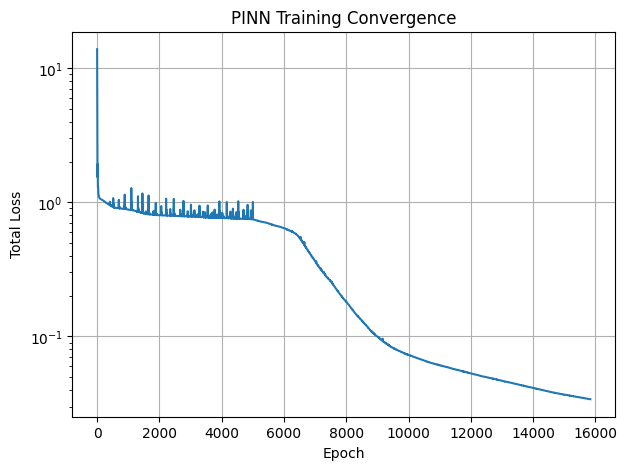

In [85]:
import matplotlib.pyplot as plt
if len(loss_history) == 0:
    print("No loss history (model not trained in this session).")
else:
    plt.figure(figsize=(7, 5))

    plt.semilogy(
        loss_history
    )

    plt.xlabel("Epoch")
    plt.ylabel("Total Loss")
    plt.title("PINN Training Convergence")

    plt.grid(True)
    plt.show()

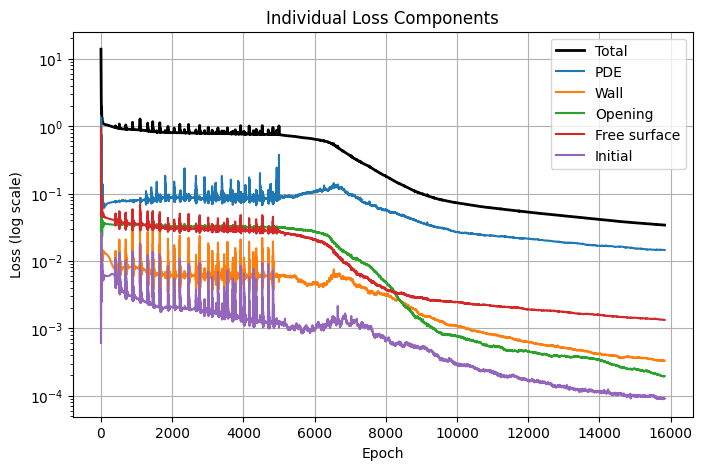

In [86]:
import numpy as np
# [CHANGED] components: pde, wall, opening, inlet, initial (+ total)
if len(loss_components_history) == 0:
    print("No loss history (model not trained in this session).")
else:
    components = np.array(loss_components_history)
    labels = ["PDE", "Wall", "Opening", "Free surface", "Initial"]

    plt.figure(figsize=(8, 5))
    plt.semilogy(loss_history, "k", lw=2, label="Total")
    for i, label in enumerate(labels):
        plt.semilogy(components[:, i], label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.title("Individual Loss Components")
    plt.legend()
    plt.grid(True)
    plt.show()

In [87]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [88]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)
v_pred = v_pred.reshape(Ny, Nx)
p_dynamic_pred = p_dynamic_pred.reshape(Ny, Nx)

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * Y
p_pred = p_dynamic_pred + p_hydrostatic


In [89]:
# import numpy as np

# # Define coordinate arrays
# x = np.array([1, 2, 3])
# y = np.array([4, 5])

# # Generate coordinate matrices
# X, Y = np.meshgrid(x, y)

# print("X Matrix:\n", X)
# print("\nY Matrix:\n", Y)


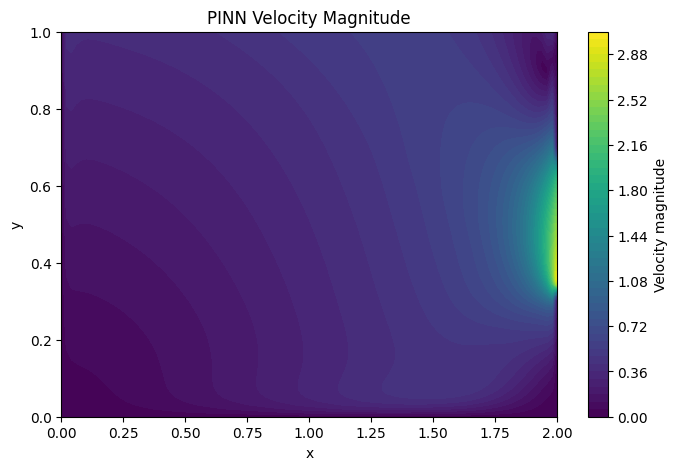

In [90]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

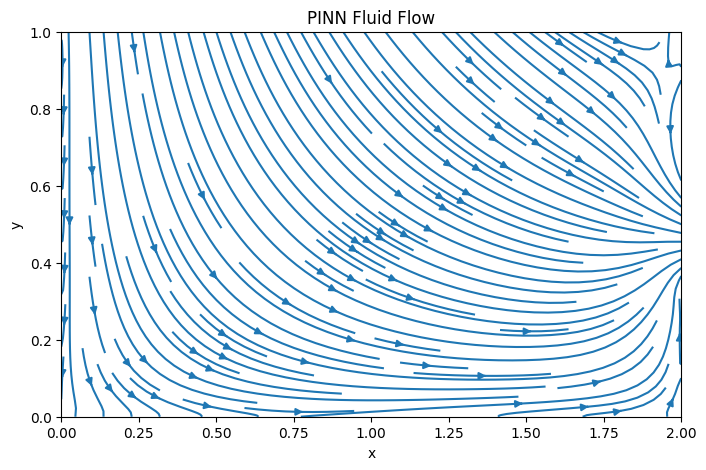

In [91]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow")

plt.show()

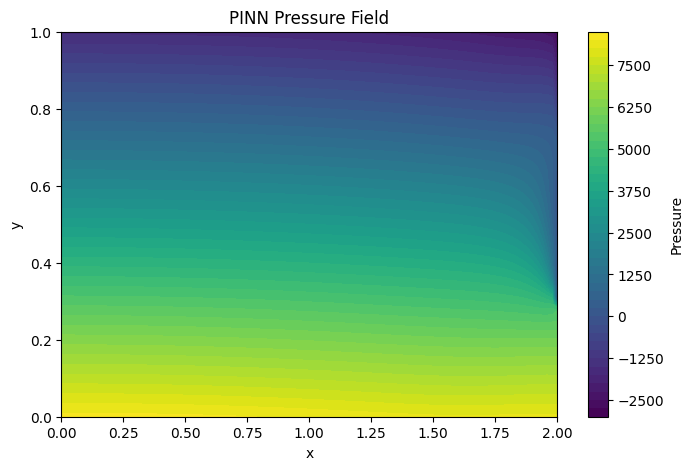

In [92]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [93]:
# Generating opening points for EVALUATION at t = T
# [CHANGED] renamed X_open -> X_open_eval; the old code overwrote the training tensor X_open here
N_open_eval = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open_eval)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open_eval = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open_eval.shape

torch.Size([500, 3])

In [94]:
with torch.no_grad():

    opening_prediction = model(X_open_eval)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)   P = p_dyn - rho*g*y
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

In [95]:
for i in range(0, N_open_eval, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )

y = 0.300 m | u = -0.19318 m/s | v = 0.19430 m/s | p = 647.24683 Pa
y = 0.340 m | u = 1.40517 m/s | v = 2.15323 m/s | p = -58.68955 Pa
y = 0.380 m | u = 2.26829 m/s | v = 1.18628 m/s | p = -51.49360 Pa
y = 0.420 m | u = 2.35726 m/s | v = 0.36181 m/s | p = 10.64401 Pa
y = 0.460 m | u = 2.20917 m/s | v = -0.28615 m/s | p = 16.58508 Pa
y = 0.500 m | u = 1.90319 m/s | v = -0.77148 m/s | p = 27.36013 Pa
y = 0.540 m | u = 1.46330 m/s | v = -1.08417 m/s | p = 57.64788 Pa
y = 0.581 m | u = 0.92356 m/s | v = -1.18431 m/s | p = 121.54988 Pa
y = 0.621 m | u = 0.36831 m/s | v = -0.98390 m/s | p = 182.32249 Pa
y = 0.661 m | u = -0.02471 m/s | v = -0.43031 m/s | p = 109.12147 Pa


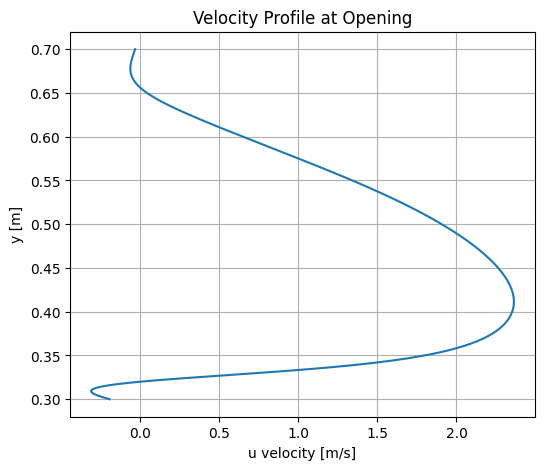

In [96]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

In [97]:
Q = np.trapezoid(
    u_open,
    y_open
)

print(
    f"Flow rate per unit depth = {Q:.6f} m^2/s"
)

Flow rate per unit depth = 0.503208 m^2/s


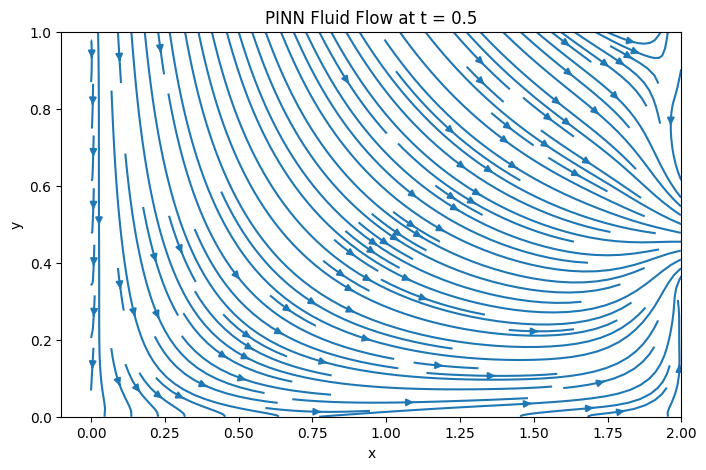

In [98]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


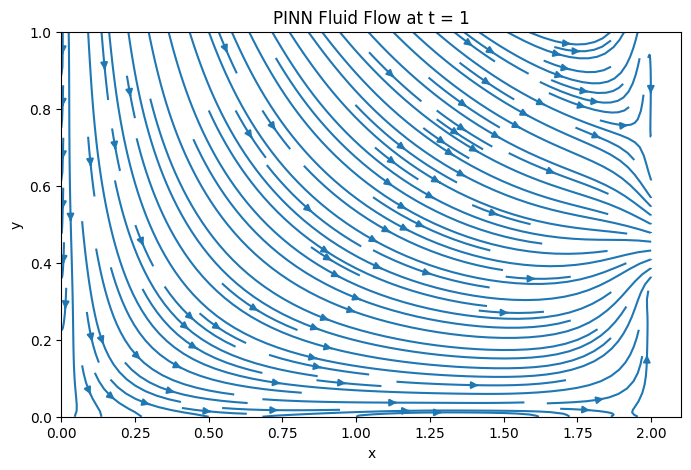

In [99]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


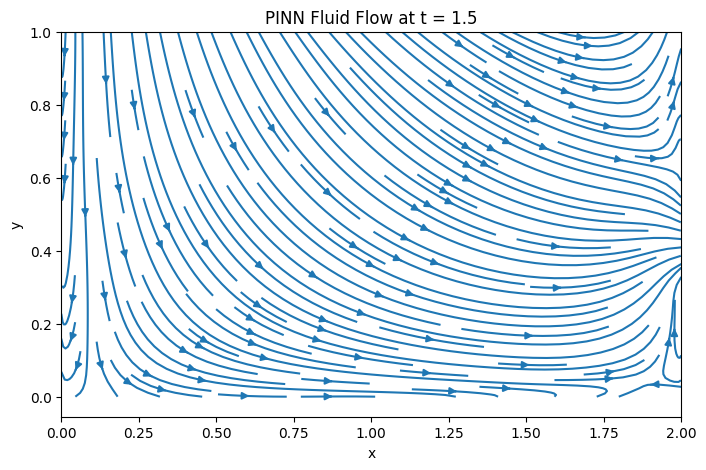

In [100]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [101]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

In [102]:
with torch.no_grad():
    test_pnts = torch.tensor([[0.2, 0.70, 0.5]], dtype=torch.float32, device=device)
    prediction = model(test_pnts)


u_pred = prediction[:, 0].item()
v_pred = prediction[:, 1].item()
p_dynamic_pred = prediction[:, 2].item()

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * 0.70
p_pred = p_dynamic_pred + p_hydrostatic

print(f"u_pred: {u_pred} m/s")
print(f"v_pred: {v_pred} m/s") 
print(f"p_pred: {p_pred} Pa")

u_pred: 0.054040491580963135 m/s
v_pred: -0.25141480565071106 m/s
p_pred: 1409.978515625 Pa


In [103]:
import numpy as np
import torch

model.eval()
rng_val = np.random.default_rng(2024)
nv = 201
t_prof = [0.25, 0.5, 0.75, 1.0]

# Generate coordinates for the opening (outlet)
y_prof = np.linspace(opening_y_min, opening_y_max, nv)
x_open_line = np.full_like(y_prof, L)

# 1. Calculate Bernoulli Estimate (Theoretical Max Speed)
y_in_s  = np.array([H])
y_out_s = np.linspace(opening_y_min, opening_y_max, 50)
head = (p_star_free_surface(y_in_s)[:, None] - p_star_outlet(y_out_s)[None, :]) / rho
U_bern = float(np.sqrt(2.0 * max(head.max(), 1e-12)))

def predict_uvp(x, y, t):
    X_ = torch.tensor(np.column_stack([x, y, t]), dtype=torch.float32, device=device)
    with torch.no_grad():
        out = model(X_).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]

print("================ PINN PHYSICS VALIDATION ================")
print(f"Bernoulli upper-bound speed (U_bern): {U_bern:.3f} m/s\n")
print(f"{'Time':<6} | {'Mass Flux In':<14} | {'Mass Flux Out':<14} | {'Imbalance':<10} | {'Max Vel (u)':<12} | {'Outflow %':<10} | {'TV Smoothness'}")
print("-" * 105)

for tp in t_prof:
    # Get predictions at the outlet
    u_out, v_out, pd_out = predict_uvp(x_open_line, y_prof, np.full_like(y_prof, tp))
    
    # Calculate Mass Flux Out (Integral of u-velocity over the opening)
    Q_out = np.trapezoid(u_out, y_prof)
    
    # Calculate Mass Flux In (Integral of v-velocity over the open top)
    xs = np.linspace(0, L, nv)
    _, vt, _ = predict_uvp(xs, np.full_like(xs, H), np.full_like(xs, tp))
    Q_in = -np.trapezoid(vt, xs)  # normal is in the -y direction
    
    # Mass Balance Imbalance
    imb = abs(Q_in - Q_out) / max(abs(Q_out), abs(Q_in), 1e-12)
    
    # Max velocity & Outflow percentage
    max_u = np.max(np.abs(u_out))
    outflow_pct = 100 * np.mean(u_out > 0)
    
    # Total Variation (TV) Smoothness
    tv = np.sum(np.abs(np.diff(u_out))) / max(np.ptp(u_out), 1e-12)
    
    print(f"{tp:<6.2f} | {Q_in:<14.5f} | {Q_out:<14.5f} | {imb:<10.2%} | {max_u:<12.3f} | {outflow_pct:<10.1f} | {tv:.2f}")

print("\n--- Diagnostic Guide ---")
print("1. Imbalance: Should be < 10%. (If high, mass is 'leaking' and continuity loss is too weak).")
print("2. Max Vel (u): Should be a reasonable fraction of U_bern (not exceeding it, not practically 0).")
print("3. Outflow %: Should be ~100% (flow is going out, not getting sucked backward).")
print("4. TV Smoothness: Should be 1.0 - 3.0 (If >> 3, the profile is noisy/oscillating).")

================ PINN PHYSICS VALIDATION ================
Bernoulli upper-bound speed (U_bern): 3.706 m/s

Time   | Mass Flux In   | Mass Flux Out  | Imbalance  | Max Vel (u)  | Outflow %  | TV Smoothness
---------------------------------------------------------------------------------------------------------
0.25   | 0.66030        | 0.63589        | 3.70%      | 2.894        | 91.5       | 2.03
0.50   | 0.59027        | 0.61669        | 4.28%      | 2.735        | 89.6       | 2.01
0.75   | 0.52984        | 0.55871        | 5.17%      | 2.535        | 85.6       | 2.00
1.00   | 0.48118        | 0.50321        | 4.38%      | 2.363        | 83.6       | 1.96

--- Diagnostic Guide ---
1. Imbalance: Should be < 10%. (If high, mass is 'leaking' and continuity loss is too weak).
2. Max Vel (u): Should be a reasonable fraction of U_bern (not exceeding it, not practically 0).
3. Outflow %: Should be ~100% (flow is going out, not getting sucked backward).
4. TV Smoothness: Should be 1.0 - 3.0

In [104]:
import numpy as np
import torch

# Ensure the model is in evaluation mode
model.eval()

# Parameters based on your setup
rho = 1000.0
g = 9.81
L = 2.0
H = 1.0

# ==========================================
# Checks A & B: Outlet metrics at t = 0.5
# ==========================================
N_eval = 500
y_eval = np.linspace(0.30, 0.70, N_eval)
x_eval = np.full_like(y_eval, L)
t_eval_outlet = np.full_like(y_eval, 0.5)

X_eval_tensor = torch.tensor(
    np.column_stack([x_eval, y_eval, t_eval_outlet]), 
    dtype=torch.float32, 
    device=device
)

with torch.no_grad():
    pred = model(X_eval_tensor)
    u_out = pred[:, 0].cpu().numpy()
    p_dyn_out = pred[:, 2].cpu().numpy()

# Reconstruct physical pressure:
# P = p_dynamic - rho*g*y
P_physical = p_dyn_out - (rho * g * y_eval)

# Check A calculations
mean_P = np.mean(np.abs(P_physical))
max_P = np.max(np.abs(P_physical))
rmse_P = np.sqrt(np.mean(P_physical**2))

print("--- A. Outlet Pressure (P) at t=0.5 ---")
print(f"Mean |P|: {mean_P:.4f} Pa")
print(f"Max  |P|: {max_P:.4f} Pa")
print(f"RMSE (P): {rmse_P:.4f} Pa\n")

# Check B calculations
Q = np.trapezoid(u_out, y_eval)

print("--- B. Outlet Flow Rate (Q) at t=0.5 ---")
print(f"Q = {Q:.6f} m^2/s\n")


# ==========================================
# Check C: PDE Residuals at new random points
# ==========================================
N_res = 10000
x_res = np.random.uniform(0, L, N_res)
y_res = np.random.uniform(0, H, N_res)
t_res = np.random.uniform(0, 1.0, N_res)

x_res_t = torch.tensor(x_res, dtype=torch.float32, device=device, requires_grad=True)
y_res_t = torch.tensor(y_res, dtype=torch.float32, device=device, requires_grad=True)
t_res_t = torch.tensor(t_res, dtype=torch.float32, device=device, requires_grad=True)

# Calculate residuals using your existing derivative functions
R_cont = continuity_loss(model, x_res_t, y_res_t, t_res_t).detach().cpu().numpy()
R_x = x_momentum_loss(model, x_res_t, y_res_t, t_res_t).detach().cpu().numpy()
R_y = y_momentum_loss(model, x_res_t, y_res_t, t_res_t).detach().cpu().numpy()

rmse_cont = np.sqrt(np.mean(R_cont**2))
rmse_x = np.sqrt(np.mean(R_x**2))
rmse_y = np.sqrt(np.mean(R_y**2))

print("--- C. PDE Residuals (New Random Points) ---")
print(f"Continuity RMSE : {rmse_cont:.6e}")
print(f"X-momentum RMSE : {rmse_x:.6e}")
print(f"Y-momentum RMSE : {rmse_y:.6e}")

--- A. Outlet Pressure (P) at t=0.5 ---
Mean |P|: 99.6249 Pa
Max  |P|: 1148.0200 Pa
RMSE (P): 152.1850 Pa

--- B. Outlet Flow Rate (Q) at t=0.5 ---
Q = 0.616688 m^2/s

--- C. PDE Residuals (New Random Points) ---
Continuity RMSE : 2.654122e+00
X-momentum RMSE : 2.392528e+01
Y-momentum RMSE : 1.650566e+00


In [105]:
# model = PINNModel()
# num1 = torch.tensor([[2.0]], dtype=torch.float32, device=device)
# num2 = torch.tensor([[3.0]], dtype=torch.float32, device=device)
# num3 = torch.tensor([[4.0]], dtype=torch.float32, device=device)

# output = model(num1, num2, num3)

# u = output[..., 0]
# v = output[..., 1]

# print(u, v)

In [106]:
# Try -> 0.3 - 0.8
# try -> 0.3 - 0.9
# try -> 0.1 - 0.7
# try -> 0.2 - 0.7
# try -> actual naviar stokes equation 

In [107]:
# ================= Helpers for validation =================
model.eval()
if not model_is_trained:
    print("!" * 70)
    print("WARNING: model is NOT trained (no training run / checkpoint). Numbers below are meaningless.")
    print("!" * 70)

rng_val = np.random.default_rng(2024)           # different from the training seed
nv = 201
t_check = np.linspace(0.0, T, 11)
report = {}                                      # filled below, printed in the final report

def predict_uvp(x, y, t):
    X_ = torch.tensor(np.column_stack([x, y, t]), dtype=torch.float32, device=device)
    with torch.no_grad():
        out = model(X_).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]

def physical_pressure(p_dyn, y):
    return p_dyn - rho * g * y                    # P = p_dyn - rho g y

def pde_residuals(X_np, chunk=5000):
    # returns residuals AND the pressure-gradient magnitude (a natural scale to judge the momentum residual)
    Rc, Rx, Ry, Gx, Gy = [], [], [], [], []
    for i in range(0, len(X_np), chunk):
        Xc = torch.tensor(X_np[i:i + chunk], dtype=torch.float32, device=device, requires_grad=True)
        x_, y_, t_ = Xc[:, 0], Xc[:, 1], Xc[:, 2]
        Rc.append(continuity_loss(model, x_, y_, t_).detach().cpu().numpy())
        Rx.append(x_momentum_loss(model, x_, y_, t_).detach().cpu().numpy())
        Ry.append(y_momentum_loss(model, x_, y_, t_).detach().cpu().numpy())
        p_ = model(Xc)[:, 2]
        gp = torch.autograd.grad(p_.sum(), Xc)[0].detach().cpu().numpy()
        Gx.append(gp[:, 0] / rho); Gy.append(gp[:, 1] / rho)
    return [np.concatenate(a) for a in (Rc, Rx, Ry, Gx, Gy)]

def rms(a):  return float(np.sqrt(np.mean(np.square(a))))
def mabs(a): return float(np.mean(np.abs(a)))
def xabs(a): return float(np.max(np.abs(a)))

# Bernoulli (inviscid, steady) estimate of the largest outlet speed:  0.5*U^2 = max(p*_in - p*_out)/rho
y_in_s  = np.array([H])
y_out_s = np.linspace(opening_y_min, opening_y_max, 50)
head = (p_star_free_surface(y_in_s)[:, None] - p_star_outlet(y_out_s)[None, :]) / rho
U_bern = float(np.sqrt(2.0 * max(head.max(), 1e-12)))
print(f"Bernoulli speed estimate (upper-bound scale for viscous, transient flow): U_bern = {U_bern:.3f} m/s")

Bernoulli speed estimate (upper-bound scale for viscous, transient flow): U_bern = 3.706 m/s


In [108]:
# Boundary and free-surface validation
def zeros(S): return np.zeros_like(S)
def ident(S): return S
def full(c): return lambda S: np.full_like(S, c)

def st_mesh(s):
    S, TT = np.meshgrid(s, t_check)
    return S.ravel(), TT.ravel()

walls = {}
walls["Bottom wall"] = (ident, zeros, np.linspace(0, L, 2 * nv))
walls["Left wall"] = (zeros, ident, np.linspace(0, H, 2 * nv))
walls["Top wall"] = None
s_right = np.concatenate([
    np.linspace(0, opening_y_min, nv, endpoint=False),
    np.linspace(opening_y_max, H, nv, endpoint=True),
])
walls["Right wall"] = (full(L), ident, s_right)

report["wall"] = {}
for name in ["Left wall", "Bottom wall", "Top wall", "Right wall"]:
    if walls[name] is None:
        report["wall"][name] = None
        continue
    xf, yf, s = walls[name]
    S, TT = st_mesh(s)
    u_, v_, _ = predict_uvp(xf(S), yf(S), TT)
    report["wall"][name] = (xabs(u_), xabs(v_))

S, TT = st_mesh(np.linspace(opening_y_min, opening_y_max, nv))
_, _, pd_ = predict_uvp(np.full_like(S, L), S, TT)
e_open = physical_pressure(pd_, S)
report["open_p"] = (xabs(e_open), rms(e_open))

x_fs_val = np.linspace(0, L, nv)
t_fs_val = np.linspace(0, T, 11)
XX, TT_fs = np.meshgrid(x_fs_val, t_fs_val)
YY = np.interp(TT_fs.ravel(), height_time_grid, height_solution)
_, v_fs, pd_fs = predict_uvp(XX.ravel(), YY, TT_fs.ravel())
v_target = dh_dt(torch.tensor(TT_fs.ravel(), dtype=torch.float32, device=device)).cpu().numpy()
e_fs_p = physical_pressure(pd_fs, YY)
e_fs_v = v_fs - v_target
report["free_surface"] = (xabs(e_fs_p), rms(e_fs_p), xabs(e_fs_v), rms(e_fs_v))

Xic = np.column_stack([rng_val.uniform(0, L, 5000), rng_val.uniform(0, H, 5000), np.zeros(5000)])
u0, v0, _ = predict_uvp(Xic[:, 0], Xic[:, 1], Xic[:, 2])
report["ic"] = (xabs(u0), xabs(v0))


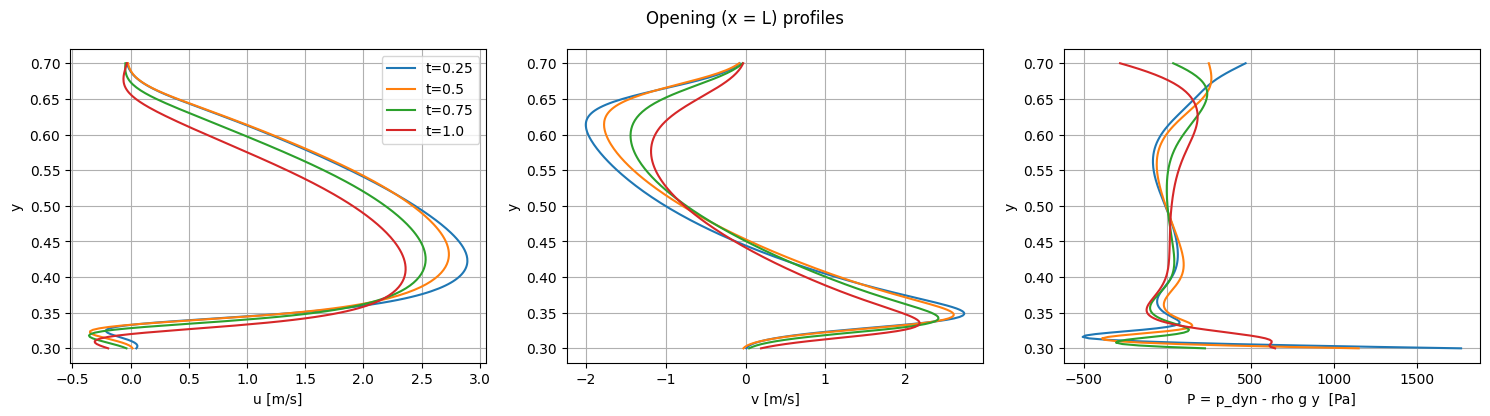

Residuals on the opening line:  RMSE(cont) = 5.127e+01 1/s,  RMSE(x-mom) = 4.315e+02,  RMSE(y-mom) = 4.806e+01 m/s^2
Opening pressure BC error (max) = 1.744e+03 Pa

  t   |  u_min     u_max     |  v_min     v_max   | %u>0 (outflow) | max|u|/U_bern | TV ratio
 0.25 |   -0.2136    2.8938 |   -2.0042    2.7436 |     91.5%      |    0.781      |   2.03
 0.50 |   -0.3496    2.7351 |   -1.7753    2.6116 |     89.6%      |    0.738      |   2.01
 0.75 |   -0.3585    2.5352 |   -1.4429    2.4206 |     85.6%      |    0.684      |   2.00
 1.00 |   -0.3086    2.3631 |   -1.1858    2.1843 |     83.6%      |    0.638      |   1.96
  (TV ratio ~1-3: smooth profile; >>3: oscillatory.  max|u|/U_bern should be O(0.1-1); ~1e-4 means 'no flow'.)

  t   |  Q_in (open top)  Q_out (opening) [m^2/s]  | rel. imbalance
 0.25 |      0.66030       0.63589   |    3.70%
 0.50 |      0.59027       0.61669   |    4.28%
 0.75 |      0.52984       0.55871   |    5.17%
 1.00 |      0.48118       0.50321   |    4.38%


In [109]:
# ================= STEP 9 : opening velocity solution =================
t_prof = [0.25, 0.5, 0.75, 1.0]
y_prof = np.linspace(opening_y_min, opening_y_max, nv)
x_open_line = np.full_like(y_prof, L)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
report["open_profile"] = {}
for tp in t_prof:
    u_, v_, pd_ = predict_uvp(x_open_line, y_prof, np.full_like(y_prof, tp))
    P_ = physical_pressure(pd_, y_prof)
    report["open_profile"][tp] = (u_, v_, P_)
    ax[0].plot(u_, y_prof, label=f"t={tp}"); ax[1].plot(v_, y_prof); ax[2].plot(P_, y_prof)
ax[0].set_xlabel("u [m/s]"); ax[1].set_xlabel("v [m/s]"); ax[2].set_xlabel("P = p_dyn - rho g y  [Pa]")
for a in ax: a.set_ylabel("y"); a.grid(True)
ax[0].legend(); fig.suptitle("Opening (x = L) profiles"); plt.tight_layout(); plt.show()

# ---- (1) continuity + (2) momentum + (3) BC at the opening points ----
S, TT = st_mesh(np.linspace(opening_y_min, opening_y_max, nv))
Rc, Rx, Ry, Gx, Gy = pde_residuals(np.column_stack([np.full_like(S, L), S, TT]))
print("Residuals on the opening line:  "
      f"RMSE(cont) = {rms(Rc):.3e} 1/s,  RMSE(x-mom) = {rms(Rx):.3e},  RMSE(y-mom) = {rms(Ry):.3e} m/s^2")
print(f"Opening pressure BC error (max) = {report['open_p'][0]:.3e} Pa")

# ---- (4) direction of flow, (5) magnitude, (6) smoothness ----
print("\n  t   |  u_min     u_max     |  v_min     v_max   | %u>0 (outflow) | max|u|/U_bern | TV ratio")
report["u_all"] = []; report["v_all"] = []
for tp in t_prof:
    u_, v_, P_ = report["open_profile"][tp]
    report["u_all"].append(u_); report["v_all"].append(v_)
    tv = np.sum(np.abs(np.diff(u_))) / max(np.ptp(u_), 1e-12)
    print(f" {tp:4.2f} | {u_.min():9.4f} {u_.max():9.4f} | {v_.min():9.4f} {v_.max():9.4f} | "
          f"{100*np.mean(u_ > 0):8.1f}%      | {np.max(np.abs(u_))/U_bern:8.3f}      | {tv:6.2f}")
print("  (TV ratio ~1-3: smooth profile; >>3: oscillatory.  max|u|/U_bern should be O(0.1-1); ~1e-4 means 'no flow'.)")

# ---- mass balance: flux in (inlet) must equal flux out (opening) at every time ----
print("\n  t   |  Q_in (open top)  Q_out (opening) [m^2/s]  | rel. imbalance")
report["imbalance"] = []
for tp in t_prof:
    u_, v_, _ = report["open_profile"][tp]
    Q_out = np.trapezoid(u_, y_prof)
    xs = np.linspace(0, L, nv)
    _, vt, _ = predict_uvp(xs, np.full_like(xs, H), np.full_like(xs, tp))
    Q_in = -np.trapezoid(vt, xs)                # inward normal at the open top is -y
    imb = abs(Q_in - Q_out) / max(abs(Q_out), abs(Q_in), 1e-12)
    report["imbalance"].append(imb)
    print(f" {tp:4.2f} | {Q_in:12.5f} {Q_out:13.5f}   | {imb:8.2%}")

In [110]:
# ================= STEP 10 : PDE residual on FRESH collocation points =================
N_val = 20000
X_val = np.column_stack([rng_val.uniform(0, L, N_val), rng_val.uniform(0, H, N_val), rng_val.uniform(0, T, N_val)])
Rc, Rx, Ry, Gx, Gy = pde_residuals(X_val)

report["pde"] = {
    "Continuity": (mabs(Rc), rms(Rc), xabs(Rc)),
    "X-momentum": (mabs(Rx), rms(Rx), xabs(Rx)),
    "Y-momentum": (mabs(Ry), rms(Ry), xabs(Ry)),
}
report["pde_rel_x"] = rms(Rx) / max(rms(Gx), 1e-12)     # residual relative to the pressure-gradient term
report["pde_rel_y"] = rms(Ry) / max(rms(Gy), 1e-12)

print(f"{'':12s} {'mean|R|':>12s} {'RMSE':>12s} {'max|R|':>12s}")
for k, (a, b, c) in report["pde"].items():
    print(f"{k:12s} {a:12.3e} {b:12.3e} {c:12.3e}")
print(f"\nRMSE(R_x) / RMS(p_x/rho) = {report['pde_rel_x']:.3e},   RMSE(R_y) / RMS(p_y/rho) = {report['pde_rel_y']:.3e}")
print("A small residual only says the network solves the PDE approximately; it does NOT prove the solution is right.")

                  mean|R|         RMSE       max|R|
Continuity      1.047e-01    8.549e-01    5.364e+01
X-momentum      1.456e-01    1.784e+00    1.118e+02
Y-momentum      9.509e-02    9.782e-01    4.963e+01

RMSE(R_x) / RMS(p_x/rho) = 3.928e-01,   RMSE(R_y) / RMS(p_y/rho) = 4.800e-01
A small residual only says the network solves the PDE approximately; it does NOT prove the solution is right.


In [111]:
# ================= STEP 11 : comparison with a reference (analytical / CFD) solution =================
# There is NO closed-form solution for this geometry (tank + opening + impulsive start), so a trusted CFD result
# (OpenFOAM, COMSOL, Fluent, ...) is required.  It must use the SAME geometry, nu, rho, g, initial condition,
# boundary conditions (open top with P = 0, outlet P = 0) and the SAME pressure reference.
#
# Expected file format (numpy .npz, one row per sample point):
#     x, y, t   : coordinates
#     u, v      : velocity components [m/s]
#     p         : PHYSICAL GAUGE pressure P (outlet = 0), NOT the modified pressure p_dyn
REFERENCE_FILE = "reference_solution.npz"
report["ref"] = None

def rel_l2(a, b): return float(np.linalg.norm(a - b) / max(np.linalg.norm(b), 1e-12))

if not os.path.exists(REFERENCE_FILE):
    print(f"'{REFERENCE_FILE}' not found -> NO reference comparison performed (accuracy against truth is UNVERIFIED).")
else:
    ref = np.load(REFERENCE_FILE)
    xr, yr, tr, ur, vr, pr = (ref[k] for k in ("x", "y", "t", "u", "v", "p"))
    up, vp, pdp = predict_uvp(xr, yr, tr)
    pp = physical_pressure(pdp, yr)
    report["ref"] = {}
    print(f"{'':3s} {'MSE':>12s} {'RMSE':>12s} {'rel L2':>12s}")
    for name, a, b in (("u", up, ur), ("v", vp, vr), ("p", pp, pr)):
        mse = float(np.mean((a - b) ** 2))
        report["ref"][name] = (mse, np.sqrt(mse), rel_l2(a, b))
        print(f"{name:3s} {mse:12.4e} {np.sqrt(mse):12.4e} {rel_l2(a, b):12.4e}")

    # ---- contours + streamlines at the reference time closest to T ----
    from scipy.interpolate import griddata
    t_cmp = tr[np.argmin(np.abs(tr - T))]
    m = np.isclose(tr, t_cmp)
    gx, gy = np.meshgrid(np.linspace(0, L, 200), np.linspace(0, H, 100))
    interp = lambda f: griddata((xr[m], yr[m]), f[m], (gx, gy), method="linear")
    ur_g, vr_g, pr_g = interp(ur), interp(vr), interp(pr)
    up_, vp_, pdp_ = predict_uvp(gx.ravel(), gy.ravel(), np.full(gx.size, t_cmp))
    up_g, vp_g = up_.reshape(gx.shape), vp_.reshape(gx.shape)
    pp_g = physical_pressure(pdp_, gy.ravel()).reshape(gx.shape)

    for title, A, B in (("|velocity|", np.hypot(up_g, vp_g), np.hypot(ur_g, vr_g)), ("pressure P", pp_g, pr_g)):
        fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
        lv = np.linspace(np.nanmin(B), np.nanmax(B), 40)
        for a, F, tt in zip(ax[:2], (A, B), ("PINN", "Reference")):
            cs = a.contourf(gx, gy, F, levels=lv, extend="both"); a.set_title(f"{tt}  {title}  (t={t_cmp:.2f})"); plt.colorbar(cs, ax=a)
        cs = ax[2].contourf(gx, gy, A - B, levels=40); ax[2].set_title("PINN - Reference"); plt.colorbar(cs, ax=ax[2])
        plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
    ax[0].streamplot(gx, gy, up_g, vp_g, density=1.5); ax[0].set_title("PINN streamlines")
    ax[1].streamplot(gx, gy, np.nan_to_num(ur_g), np.nan_to_num(vr_g), density=1.5); ax[1].set_title("Reference streamlines")
    plt.tight_layout(); plt.show()

'reference_solution.npz' not found -> NO reference comparison performed (accuracy against truth is UNVERIFIED).


In [112]:
# ================= STEP 12 : final diagnostic report =================
def line(name, tup):
    return f"{name:16s}: " + ("n/a (open top, not a wall)" if tup is None else f"max|u| = {tup[0]:.3e}, max|v| = {tup[1]:.3e}")

all_u = np.concatenate(report["u_all"]); all_v = np.concatenate(report["v_all"])
print("================ PINN VALIDATION ================")
print(f"Gravity-driven flow, open top   (trained model: {model_is_trained})\n")
print("Boundary condition errors:")
for n in ["Left wall", "Bottom wall", "Top wall", "Right wall"]:
    print("  " + line(n, report["wall"][n]))
print(f"  Opening pressure: max|p_dyn - rho g y| = {report['open_p'][0]:.3e} Pa (rms {report['open_p'][1]:.3e})")
print(f"  Free-surface pressure: max error = {report['free_surface'][0]:.3e} Pa (rms {report['free_surface'][1]:.3e})\n")
print("Initial condition:")
print(f"  max |u| = {report['ic'][0]:.3e}\n  max |v| = {report['ic'][1]:.3e}\n")
print("PDE residual (fresh points):")
print(f"  Continuity RMSE : {report['pde']['Continuity'][1]:.3e}")
print(f"  X-momentum RMSE : {report['pde']['X-momentum'][1]:.3e}   (relative to p_x/rho: {report['pde_rel_x']:.3e})")
print(f"  Y-momentum RMSE : {report['pde']['Y-momentum'][1]:.3e}   (relative to p_y/rho: {report['pde_rel_y']:.3e})\n")
print("Opening velocity (all t in " + str(t_prof) + "):")
print(f"  u range = [{all_u.min():.4f}, {all_u.max():.4f}] m/s      Bernoulli scale U_bern = {U_bern:.3f} m/s")
print(f"  v range = [{all_v.min():.4f}, {all_v.max():.4f}] m/s")
print(f"  max mass-flux imbalance (inlet vs outlet) = {max(report['imbalance']):.2%}\n")
print("Reference error:")
if report["ref"] is None:
    print("  NOT AVAILABLE (no reference solution file) -> accuracy vs. truth is unverified")
else:
    for k in ("u", "v", "p"):
        print(f"  {k} RMSE = {report['ref'][k][1]:.3e}   rel L2 = {report['ref'][k][2]:.3e}")
print("\n==================================================")

# ---- automatic verdicts (heuristic tolerances, adjust to your accuracy needs) ----
tol_vel, tol_p, tol_res = 0.01 * U_bern, 0.01 * p_scale, 0.05
wall_ok = all(max(v) < tol_vel for v in report["wall"].values() if v is not None)
bc_ok   = wall_ok and report["open_p"][0] < tol_p and report["free_surface"][0] < tol_p and report["free_surface"][2] < tol_vel
ic_ok   = max(report["ic"]) < tol_vel
pde_ok  = report["pde_rel_x"] < tol_res and report["pde_rel_y"] < tol_res and report["pde"]["Continuity"][1] < tol_res * U_bern / H
u_out   = np.max(np.abs(all_u))
phys_ok = (np.mean(all_u[len(all_u)//4:] > 0) > 0.95) and (0.05 < u_out / U_bern < 1.2) and (max(report["imbalance"]) < 0.10)

yn = lambda b: "YES" if b else "NO"
print(f"1. Physically consistent (outflow direction, magnitude vs Bernoulli, mass balance) : {yn(phys_ok)}")
print(f"2. Numerically satisfying the PDE (relative residual < {tol_res:.0%})                : {yn(pde_ok)}")
print(f"3. Satisfying all BC / IC (wall, outlet P, open-top P, t=0)                              : {yn(bc_ok and ic_ok)}")
if report["ref"] is None:
    print("4. Quantitatively accurate vs reference                                             : UNKNOWN (no reference)")
else:
    ok = all(report["ref"][k][2] < 0.05 for k in ("u", "v", "p"))
    print(f"4. Quantitatively accurate vs reference (rel L2 < 5%)                               : {yn(ok)}")

================ PINN VALIDATION ================
Gravity-driven flow, open top   (trained model: True)

Boundary condition errors:
  Left wall       : max|u| = 2.942e-02, max|v| = 9.070e-02
  Bottom wall     : max|u| = 4.114e-02, max|v| = 5.988e-02
  Top wall        : n/a (open top, not a wall)
  Right wall      : max|u| = 1.642e-01, max|v| = 2.015e-01
  Opening pressure: max|p_dyn - rho g y| = 1.744e+03 Pa (rms 2.041e+02)
  Free-surface pressure: max error = 4.825e+03 Pa (rms 1.120e+03)

Initial condition:
  max |u| = 6.464e-02
  max |v| = 1.174e-01

PDE residual (fresh points):
  Continuity RMSE : 8.549e-01
  X-momentum RMSE : 1.784e+00   (relative to p_x/rho: 3.928e-01)
  Y-momentum RMSE : 9.782e-01   (relative to p_y/rho: 4.800e-01)

Opening velocity (all t in [0.25, 0.5, 0.75, 1.0]):
  u range = [-0.3585, 2.8938] m/s      Bernoulli scale U_bern = 3.706 m/s
  v range = [-2.0042, 2.7436] m/s
  max mass-flux imbalance (inlet vs outlet) = 5.17%

Reference error:
  NOT AVAILABLE (no r

## Roadmap and remaining modelling limitations

**Phase 1 (this notebook):** rectangular domain, open top / reservoir, right outlet, gravity, PINN predicts `(u, v, p*)`.
**Phase 2:** validate (BC, IC, continuity, momentum, mass conservation, profiles) - this section.
**Phase 3 (later):** free surface / changing water level, realistic water viscosity, transient draining, CFD comparison, and - as a *separate* experiment - pressure-driven flow `p_in > p_out`.

Limitations of the current model:

1. **Constant-level reservoir, not a draining tank.** The top is held at `P = 0` (level `y = H`) for the whole simulation, so the water level never drops. Fine as a debugging problem; it is not the transient draining of a real tank.
2. **No independent reference yet.** "PDE residual ≈ 0 + BC/IC satisfied" is necessary but *not sufficient*. Provide `reference_solution.npz` for Step 11.
3. **Impulsive start.** BCs and zero IC are incompatible at `t = 0`+ (the pressure jumps instantly), which creates a sharp initial transient that PINNs resolve poorly. A smooth ramp of the top pressure is usually better.
4. **Pressure-only BCs at the top and the outlet** allow backflow/recirculation there, so the outflow-direction check in the validation is meaningful, not automatic.
5. **Viscosity.** `nu = 1e-3 m²/s` is 1000× that of water (`1e-6`), i.e. a very viscous fluid. With `nu = 1e-6` the flow is turbulent and a laminar 2-D PINN is not reliable.
6. **Scaling.** `p_dyn ~ 10⁴ Pa` while `u ~ 1 m/s`; the pressure-BC losses are normalised by `p_scale`, but a fully non-dimensional formulation is more robust. The `lambda_*` weights need tuning.
7. **2-D / laminar / incompressible** assumptions and generic PINN optimisation difficulties remain.

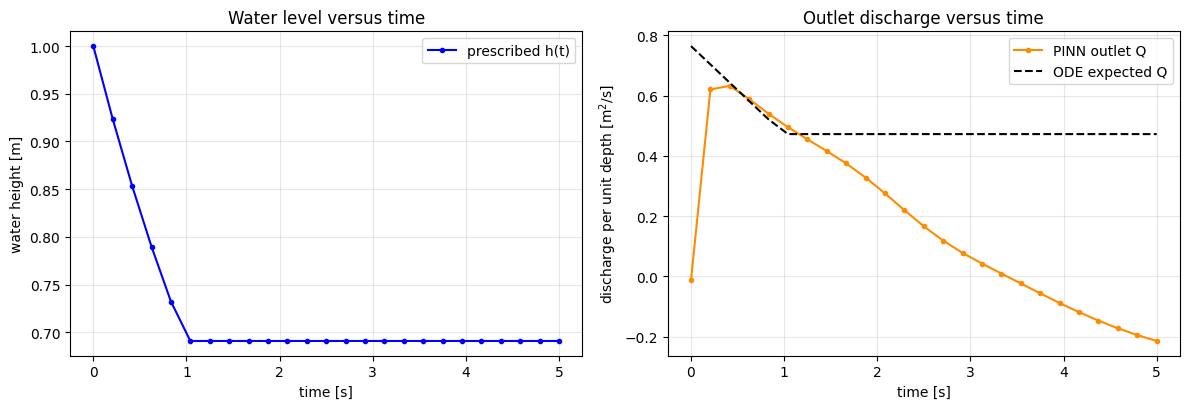

Initial water height: 1.0000 m
Final water height:   0.6909 m
Height change:        -0.3091 m
Maximum predicted outlet discharge: 0.632421 m^2/s


In [115]:
# ================= STEP 13 : time-resolved draining visualization =================
# This notebook prescribes h(t) from the draining-height ODE. The animation shows
# the PINN velocity field inside that prescribed, decreasing water region.
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

T = 5#

model.eval()

N_anim_x = 80
N_anim_y = 50
N_anim_t = 25
x_anim = np.linspace(0.0, L, N_anim_x)
y_anim = np.linspace(0.0, H, N_anim_y)
X_anim, Y_anim = np.meshgrid(x_anim, y_anim)
t_anim = np.linspace(0.0, T, N_anim_t)

# Predict all animation frames once, avoiding repeated model evaluations during redraw.
U_anim = np.empty((N_anim_t, N_anim_y, N_anim_x), dtype=np.float32)
V_anim = np.empty_like(U_anim)
for k, time_value in enumerate(t_anim):
    inputs = torch.tensor(
        np.column_stack([
            X_anim.ravel(),
            Y_anim.ravel(),
            np.full(X_anim.size, time_value),
        ]),
        dtype=torch.float32,
        device=device,
    )
    with torch.no_grad():
        prediction = model(inputs).cpu().numpy()
    U_anim[k] = prediction[:, 0].reshape(N_anim_y, N_anim_x)
    V_anim[k] = prediction[:, 1].reshape(N_anim_y, N_anim_x)

speed_anim = np.hypot(U_anim, V_anim)
max_speed = max(float(np.nanmax(speed_anim)), 1e-8)

fig_anim, ax_anim = plt.subplots(figsize=(10, 5.5))
levels = np.linspace(0.0, max_speed, 21)


def draw_frame(frame):
    ax_anim.clear()
    h_now = float(np.interp(t_anim[frame], height_time_grid, height_solution))
    water_mask = Y_anim > h_now
    speed = np.ma.array(speed_anim[frame], mask=water_mask)
    u = np.ma.array(U_anim[frame], mask=water_mask)
    v = np.ma.array(V_anim[frame], mask=water_mask)

    contour = ax_anim.contourf(X_anim, Y_anim, speed, levels=levels, cmap="viridis", extend="max")
    ax_anim.streamplot(x_anim, y_anim, u, v, color="white", density=1.0, linewidth=0.7, arrowsize=0.7)
    ax_anim.fill_between(x_anim, h_now, H, color="white", alpha=0.9, zorder=3)
    ax_anim.plot(x_anim, np.full_like(x_anim, h_now), "r-", lw=2.0, label=f"water level h={h_now:.3f} m")
    ax_anim.axvline(L, color="black", lw=1.0)
    ax_anim.set_xlim(0, L)
    ax_anim.set_ylim(0, H)
    ax_anim.set_xlabel("x [m]")
    ax_anim.set_ylabel("y [m]")
    ax_anim.set_title(f"Draining flow: t={t_anim[frame]:.3f} s")
    ax_anim.legend(loc="upper right")
    ax_anim.text(0.02, 0.03, "colour = |velocity|", transform=ax_anim.transAxes, color="black", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
    return contour,

# Display animation in Jupyter/Kaggle.
anim = FuncAnimation(fig_anim, draw_frame, frames=N_anim_t, interval=180, blit=False)
display(HTML(anim.to_jshtml()))
plt.close(fig_anim)

# Quantitative draining check: prescribed water height and PINN outlet discharge.
h_plot = np.interp(t_anim, height_time_grid, height_solution)
q_plot = []
for time_value, h_now in zip(t_anim, h_plot):
    if h_now <= opening_y_min:
        q_plot.append(0.0)
        continue
    y_limit = min(h_now, opening_y_max)
    y_line = np.linspace(opening_y_min, y_limit, 300)
    outlet_inputs = torch.tensor(
        np.column_stack([np.full_like(y_line, L), y_line, np.full_like(y_line, time_value)]),
        dtype=torch.float32,
        device=device,
    )
    with torch.no_grad():
        outlet_u = model(outlet_inputs)[:, 0].cpu().numpy()
    q_plot.append(float(np.trapezoid(outlet_u, y_line)))
q_plot = np.asarray(q_plot)

fig_summary, (ax_h, ax_q) = plt.subplots(1, 2, figsize=(12, 4.2))
ax_h.plot(t_anim, h_plot, "b-o", ms=3, label="prescribed h(t)")
ax_h.set_xlabel("time [s]")
ax_h.set_ylabel("water height [m]")
ax_h.set_title("Water level versus time")
ax_h.grid(True, alpha=0.3)
ax_h.legend()
ax_q.plot(t_anim, q_plot, "darkorange", marker="o", ms=3, label="PINN outlet Q")
ax_q.plot(t_anim, -A_tank * np.array([dh_dt_ode(h, t) for h, t in zip(h_plot, t_anim)]), "k--", label="ODE expected Q")
ax_q.set_xlabel("time [s]")
ax_q.set_ylabel("discharge per unit depth [m$^2$/s]")
ax_q.set_title("Outlet discharge versus time")
ax_q.grid(True, alpha=0.3)
ax_q.legend()
plt.tight_layout()
plt.show()

print(f"Initial water height: {h_plot[0]:.4f} m")
print(f"Final water height:   {h_plot[-1]:.4f} m")
print(f"Height change:        {h_plot[-1] - h_plot[0]:.4f} m")
print(f"Maximum predicted outlet discharge: {np.max(q_plot):.6f} m^2/s")
